<a href="https://colab.research.google.com/github/laksamanaap/244107020021-machine-leaning-course-2026-/blob/main/JS06/JS06_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

In [2]:
# Fungsi Plotting

# buat sebuah fungsi untuk menampilkan fitting data
def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)

    Y, X = np.meshgrid(y, x)

    xy = np.vstack([X.ravel(), Y.ravel()]).T

    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(
        X,
        Y,
        P,
        colors='k',
        levels=[-1, 0, 1],
        alpha=0.5,
        linestyles=['--', '-', '--']
    )

    # plot support vectors
    if plot_support:
        ax.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=300,
            linewidth=1,
            facecolors='none'
        )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

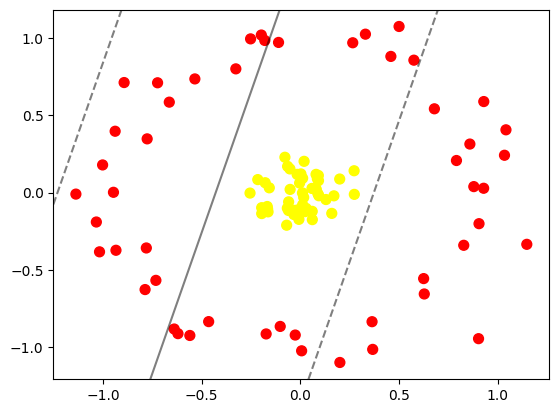

In [3]:
# Data dummy non linear
# contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles

X, y = make_circles(
    100,
    factor=.1,
    noise=.1
)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    s=50,
    cmap='autumn'
)

plot_svc_decision_function(
    clf,
    plot_support=False
)

r = np.exp(-(X**2).sum(1))

In [4]:
# Visualisasi 3D
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):

    ax = plt.subplot(projection='3d')

    ax.scatter3D(
        X[:, 0],
        X[:, 1],
        r,
        c=y,
        s=50,
        cmap='autumn'
    )

    ax.view_init(
        elev=elev,
        azim=azim
    )

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')


interact(
    plot_3D,
    elev=[-90, 45, 30, 20, 10],
    azim=(-180, 180),
    X=fixed(X),
    y=fixed(y)
)

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[ 0.00662486, -1.02612673],
       [-0.19578713, -0.09806032],
       [ 0.27248669,  0.14152281],
       [-1.00161239,  0.1792764 ],
       [ 0.02429602, -0.1238392 ],
       [-0.19752727,  1.02179634],
       [-0.16751841, -0.0903393 ],
       [ 0.01175832,  0.09325222],
       [-0.93807155,  0.39780889],
       [-0.77588406,  0.34840454],
       [-0.94656313,  0.00181423],
       [ 0.19954041,  0.08794252],
       [ 0.26558253,  0.9715862 ],
       [ 0.27355839, -0.0115767 ],
       [-0.25191396,  0.99684054],
       [ 0.67918205,  0.54332422],
       [ 0.09208444,  0.0776466 ],
       [-0.11034184,  0.97377313],
       [-0.78012224, -0.35920203],
       [ 0.82790129, -0.34182191],
       [-0.53421772,  0.73714408],
       [-0.73165599, -0.56923396],
       [ 0.62793264, -0.65756577],
       [-1.01719657, -0.3842141 ],
       [-0.16351292, -0.12504736],
       [-0.32665519,  0.80236224],
       [ 0.01095339, -0.00216276],
       [-0.17786825,  0.06390485],
       [ 1.14732945, -0.3355434 ],
       [ 0.06765836,  0.02538833],
       [ 0.07769111,  0.02623799],
       [ 0.62474719, -0.55778792],
       [ 0.0029967 ,  0.12097037],
       [ 0.2004174 , -1.10180897],
       [ 0.5002606 ,  1.07721855],
       [-0.05171459,  0.02058315],
       [-0.1955902 , -0.13608913],
       [-0.6198151 , -0.9147215 ],
       [-0.18000351,  0.98664186],
       [ 0.08075662,  0.02076158],
       [-0.21547137,  0.08419555],
       [-0.01613105,  0.11813604],
       [ 0.060796  , -0.17543618],
       [ 0.90287868, -0.94738367],
       [ 0.05901535,  0.02701713],
       [ 0.79097279,  0.20798738],
       [ 0.85893183,  0.31470205],
       [ 0.01910973,  0.20271746],
       [-0.63882689, -0.88483821],
       [ 0.07965695,  0.11820178],
       [-0.07805499,  0.22915101],
       [ 1.04171493,  0.40706847],
       [-0.00984443, -0.11161938],
       [-0.16573142, -0.10626232],
       [-0.0216779 , -0.11526003],
       [-0.06922046, -0.21157211],
       [-0.05263021,  0.15337452],
       [ 0.36339636, -0.83731728],
       [ 0.09380926, -0.02053378],
       [-0.05991043, -0.11609484],
       [-0.06442207,  0.16996474],
       [-0.025756  , -0.92389401],
       [-0.78640975, -0.62895819],
       [-1.13690176, -0.00987474],
       [ 0.12999789, -0.04498682],
       [ 0.09125091,  0.11096302],
       [-0.559614  , -0.92668848],
       [-0.15719669,  0.03091507],
       [ 0.01177396, -0.07927275],
       [ 0.45871281,  0.88300171],
       [ 0.36665441, -1.0169281 ],
       [-0.0657866 , -0.10083574],
       [-0.03253555, -0.14216554],
       [ 0.0170993 , -0.0311689 ],
       [-0.00715714, -0.17366257],
       [ 0.15940562, -0.13489265],
       [-0.66382178,  0.58644712],
       [-0.93390495, -0.37410562],
       [-0.00356218,  0.06196039],
       [-0.2547668 , -0.00319626],
       [-1.03330005, -0.19083432],
       [ 0.02960944, -0.10259974],
       [ 0.92939709,  0.59032602],
       [ 0.17015484, -0.02113454],
       [-0.89257501,  0.71361245],
       [ 0.08897861, -0.00669788],
       [ 0.57531577,  0.85869754],
       [-0.03783845, -0.11404649],
       [-0.05920064, -0.0600397 ],
       [ 0.08628022,  0.08988139],
       [ 0.32981199,  1.02729945],
       [ 1.03429021,  0.24203024],
       [-0.72310358,  0.71209119],
       [-0.17311316, -0.91673021],
       [ 0.92875812,  0.02800859],
       [ 0.06020386, -0.12163287],
       [-0.46433817, -0.83683333],
       [ 0.90526008, -0.20166412],
       [-0.10183403, -0.86801222],
       [ 0.87886507,  0.03871959]]), y=array([0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]))>

In [5]:
# Fiting model SVM
clf = SVC(
    kernel='rbf',
    C=1E6
)

clf.fit(X, y)

SVC(C=1000000.0)

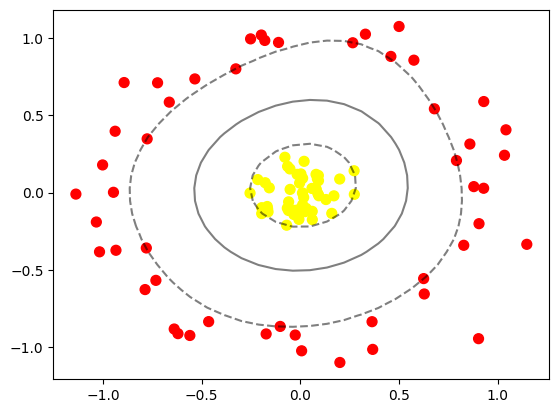

In [6]:
# Visualisasi decision boundary
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    s=50,
    cmap='autumn'
)

plot_svc_decision_function(clf)

plt.scatter(
    clf.support_vectors_[:, 0],
    clf.support_vectors_[:, 1],
    s=300,
    lw=1,
    facecolors='none'
)